[Pre-Process] Applied -10dB Cutoff.
 -> Vol1 Sparsity: 0.1% | Vol2 Sparsity: 0.1%

Shift: 55 voxels
Participating tiles: 47 / 800
Tiles voting for chosen shift: 4
Weighted score at chosen shift: 620.590


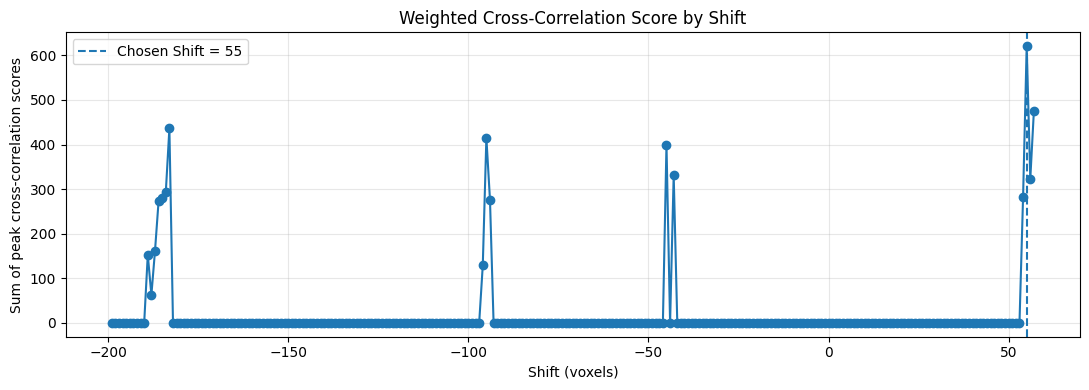

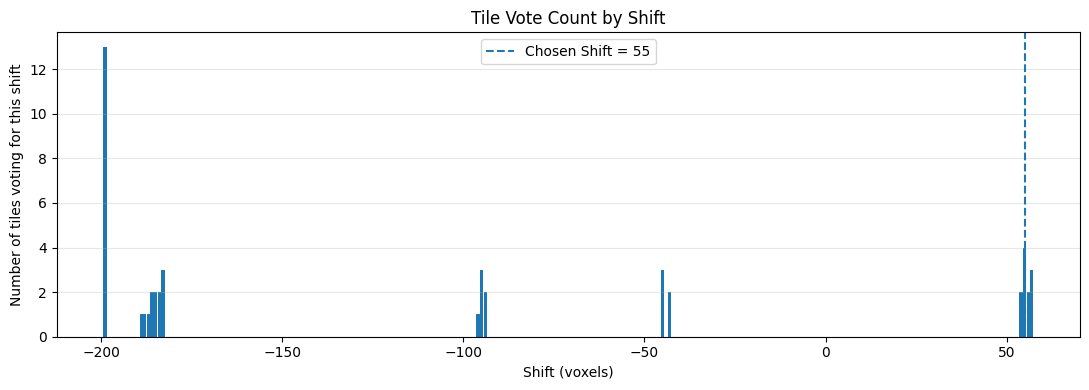

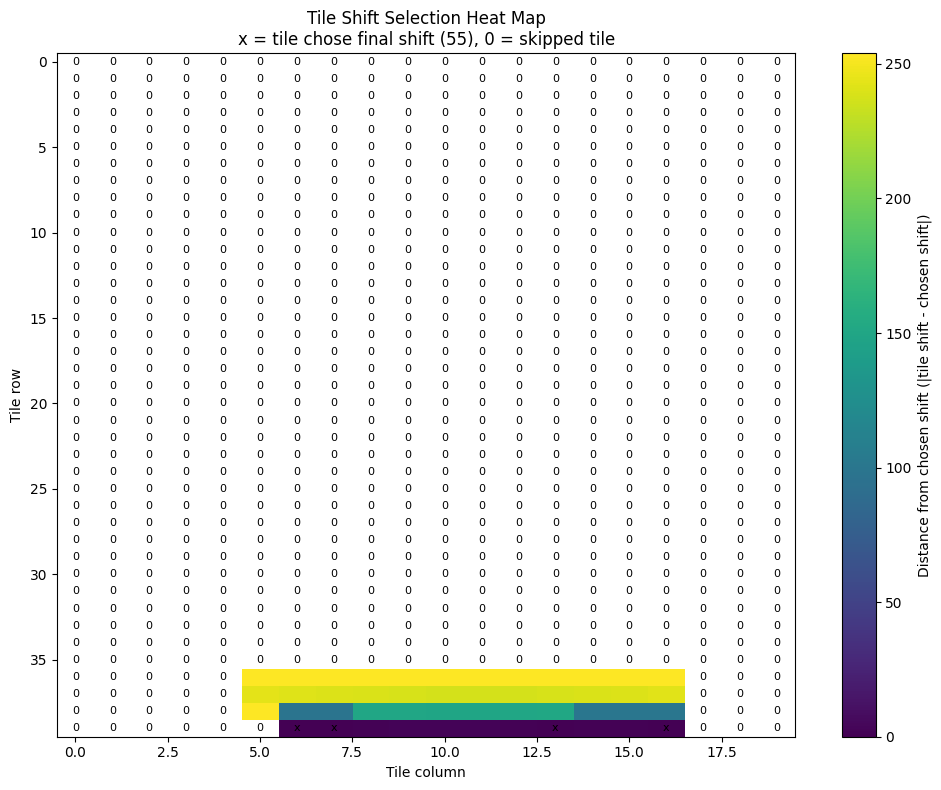


Stitcher complete.
Vol 1 threshold limits: [-10.0, 0.0]
Vol 2 threshold limits: [-10.0, 0.0]


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from pathlib import Path
import napari

# ==========================================
# 0. PRE-PROCESSING UTILITIES
# ==========================================
def apply_db_cutoff(vol, cutoff_db=-5):
    """
    Zeros out voxels more than 'cutoff_db' below the peak.
    Returns the thresholded volume and the sparsity percentage.
    """
    v_abs = np.abs(vol)
    v_max = np.max(v_abs)
    if v_max == 0:
        return vol.astype(np.float32), 0.0

    thresh = v_max * (10 ** (cutoff_db / 20))
    v_thresh = np.where(v_abs >= thresh, vol, 0)

    sparsity = (np.count_nonzero(v_thresh == 0) / v_thresh.size) * 100
    return v_thresh.astype(np.float32), sparsity


# ==========================================
# 1. DIAGNOSTIC PLOTTING
# ==========================================
def plot_stitcher_diagnostics(diag):
    """
    Creates:
      1) weighted cross-correlation score vs shift
      2) vote count vs shift
      3) tile heat map showing distance from chosen shift
    """
    shifts = diag["shift_axis"]
    weighted_scores = diag["weighted_scores"]
    vote_counts = diag["vote_counts"]
    final_shift = diag["final_shift"]
    tile_vote_map = diag["tile_vote_map"]
    tile_distance_map = diag["tile_distance_map"]

    # ---- 1. Weighted score vs shift ----
    plt.figure(figsize=(11, 4))
    plt.plot(shifts, weighted_scores, marker='o', linewidth=1.5)
    plt.axvline(final_shift, linestyle='--', linewidth=1.5, label=f'Chosen Shift = {final_shift}')
    plt.title("Weighted Cross-Correlation Score by Shift")
    plt.xlabel("Shift (voxels)")
    plt.ylabel("Sum of peak cross-correlation scores")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # ---- 2. Vote count vs shift ----
    plt.figure(figsize=(11, 4))
    plt.bar(shifts, vote_counts, width=0.9)
    plt.axvline(final_shift, linestyle='--', linewidth=1.5, label=f'Chosen Shift = {final_shift}')
    plt.title("Tile Vote Count by Shift")
    plt.xlabel("Shift (voxels)")
    plt.ylabel("Number of tiles voting for this shift")
    plt.grid(alpha=0.3, axis='y')
    plt.legend()
    plt.tight_layout()

    # ---- 3. Tile heat map ----
    # tile_distance_map:
    #   0   -> exact chosen shift
    #   >0  -> abs(tile_shift - final_shift)
    #   NaN -> skipped tile
    plt.figure(figsize=(10, 8))
    heat_data = np.ma.masked_invalid(tile_distance_map)
    im = plt.imshow(heat_data, aspect='auto', interpolation='nearest')
    cbar = plt.colorbar(im)
    cbar.set_label("Distance from chosen shift (|tile shift - chosen shift|)")

    # overlay exact matches and skipped tiles
    rows, cols = tile_vote_map.shape
    for r in range(rows):
        for c in range(cols):
            if np.isnan(tile_vote_map[r, c]):
                plt.text(c, r, "0", ha='center', va='center', fontsize=8)
            elif int(tile_vote_map[r, c]) == final_shift:
                plt.text(c, r, "x", ha='center', va='center', fontsize=8)

    plt.title(
        f"Tile Shift Selection Heat Map\n"
        f"x = tile chose final shift ({final_shift}), 0 = skipped tile"
    )
    plt.xlabel("Tile column")
    plt.ylabel("Tile row")
    plt.tight_layout()

    plt.show()


# ==========================================
# 2. THE STITCHER ENGINE (Profile-Based Consensus)
# ==========================================
def run_stitcher_test(vol1, vol2, axis=2, grid=(60, 20), expected=0, tolerance=200, cutoff_db=-5):
    v1, s1 = apply_db_cutoff(vol1, cutoff_db)
    v2, s2 = apply_db_cutoff(vol2, cutoff_db)

    print(f"[Pre-Process] Applied {cutoff_db}dB Cutoff.")
    print(f" -> Vol1 Sparsity: {s1:.1f}% | Vol2 Sparsity: {s2:.1f}%")

    ignore_top = 30
    z_dim, y_dim, x_dim = v1.shape
    z_start, z_end = ignore_top, z_dim

    tile_z = (z_end - z_start) // grid[0]
    tile_y = y_dim // grid[1]

    if tile_z <= 0 or tile_y <= 0:
        raise ValueError(
            f"Grid {grid} is too fine for volume shape {v1.shape} after ignore_top={ignore_top}."
        )

    all_shifts = []
    all_weights = []

    # Per-tile vote map
    tile_vote_map = np.full(grid, np.nan, dtype=float)

    for r in range(grid[0]):
        for c in range(grid[1]):
            zs, ze = z_start + (r * tile_z), z_start + ((r + 1) * tile_z)
            ys, ye = c * tile_y, (c + 1) * tile_y

            prof1 = np.mean(np.abs(v1[zs:ze, ys:ye, :]), axis=(0, 1))
            prof2 = np.mean(np.abs(v2[zs:ze, ys:ye, :]), axis=(0, 1))

            if np.std(prof1) < 1e-6 or np.max(prof1) == 0:
                continue

            p1_n = (prof1 - np.mean(prof1)) / (np.std(prof1) + 1e-10)
            p2_n = (prof2 - np.mean(prof2)) / (np.std(prof2) + 1e-10)

            corr = correlate(p1_n, p2_n, mode='full')
            lags = correlation_lags(len(p1_n), len(p2_n), mode='full')

            mask = (lags >= expected - tolerance) & (lags <= expected + tolerance)
            if not np.any(mask):
                continue

            corr[~mask] = -np.inf

            peak_idx = np.argmax(corr)
            chosen_lag = int(lags[peak_idx])
            chosen_weight = float(corr[peak_idx])

            if not np.isfinite(chosen_weight):
                continue

            all_shifts.append(chosen_lag)
            all_weights.append(chosen_weight)
            tile_vote_map[r, c] = chosen_lag

    if not all_shifts:
        raise ValueError(f"No features survived the {cutoff_db}dB cutoff.")

    # Weighted consensus histogram
    lag_min, lag_max = np.min(all_shifts), np.max(all_shifts)
    shift_axis = np.arange(lag_min, lag_max + 1)

    weighted_scores = np.zeros_like(shift_axis, dtype=float)
    vote_counts = np.zeros_like(shift_axis, dtype=int)

    shift_to_idx = {int(s): i for i, s in enumerate(shift_axis)}

    for s, w in zip(all_shifts, all_weights):
        idx = shift_to_idx[int(s)]
        weighted_scores[idx] += w
        vote_counts[idx] += 1

    final_shift = int(shift_axis[np.argmax(weighted_scores)])

    # Distance heat map: 0 means exact match, larger = further from consensus
    tile_distance_map = np.full(grid, np.nan, dtype=float)
    valid_mask = ~np.isnan(tile_vote_map)
    tile_distance_map[valid_mask] = np.abs(tile_vote_map[valid_mask] - final_shift)

    print(f"\nShift: {final_shift} voxels")
    print(f"Participating tiles: {len(all_shifts)} / {grid[0] * grid[1]}")
    print(f"Tiles voting for chosen shift: {np.sum(np.array(all_shifts) == final_shift)}")
    print(f"Weighted score at chosen shift: {weighted_scores[shift_to_idx[final_shift]]:.3f}")

    diagnostics = {
        "shift_axis": shift_axis,
        "weighted_scores": weighted_scores,
        "vote_counts": vote_counts,
        "final_shift": final_shift,
        "tile_vote_map": tile_vote_map,
        "tile_distance_map": tile_distance_map,
        "all_shifts": np.array(all_shifts, dtype=int),
        "all_weights": np.array(all_weights, dtype=float),
    }

    return final_shift, v1, v2, diagnostics


# ==========================================
# 3. STANDALONE STITCHER EXECUTION
# ==========================================
if __name__ == "__main__":
    IN_DIR = Path.cwd().parent / 'DATA' / '2D TFM Data' / "FeC Smile 3MHz 04022026 Filtered"

    vol1_raw = np.load(IN_DIR / "FeC_40_6_filtered_3D_TFM.npy")
    vol2_raw = np.load(IN_DIR / "FeC_40_5_filtered_3D_TFM.npy")

    stitch_shift, v1_thresholded, v2_thresholded, diagnostics = run_stitcher_test(
        vol1_raw,
        vol2_raw,
        grid=(40, 20),
        cutoff_db=-10
    )

    # Plot requested diagnostics
    plot_stitcher_diagnostics(diagnostics)

    # Raw Data Limits
    clim_raw_1 = sorted([float(np.percentile(vol1_raw, 0.1)), float(np.percentile(vol1_raw, 99.9))])
    if clim_raw_1[0] == clim_raw_1[1]:
        clim_raw_1 = [clim_raw_1[0], clim_raw_1[0] + 1]

    clim_raw_2 = sorted([float(np.percentile(vol2_raw, 0.1)), float(np.percentile(vol2_raw, 99.9))])
    if clim_raw_2[0] == clim_raw_2[1]:
        clim_raw_2 = [clim_raw_2[0], clim_raw_2[0] + 1]

    # Thresholded Data Limits
    clim_thresh_1 = sorted([float(np.min(v1_thresholded)), float(np.max(v1_thresholded))])
    if clim_thresh_1[0] == clim_thresh_1[1]:
        clim_thresh_1 = [0, 1]

    clim_thresh_2 = sorted([float(np.min(v2_thresholded)), float(np.max(v2_thresholded))])
    if clim_thresh_2[0] == clim_thresh_2[1]:
        clim_thresh_2 = [0, 1]

    viewer = napari.Viewer(title=f"Stitcher Result Testing dB Cutoff")

    # Vol 1 raw + thresholded
    viewer.add_image(
        vol1_raw,
        name='Vol 1 (Raw)',
        colormap='cyan',
        contrast_limits=clim_raw_1,
        opacity=0.35
    )
    viewer.add_image(
        v1_thresholded,
        name='Vol 1 (-2dB Hotspots)',
        colormap='yellow',
        contrast_limits=clim_thresh_1,
        opacity=1.0
    )

    # Shift to apply to volume 2
    trans = [0, 0, 0]
    trans[2] = stitch_shift

    # Vol 2 raw + thresholded, both shifted
    viewer.add_image(
        vol2_raw,
        name=f'Vol 2 Raw (Shifted {stitch_shift}px)',
        colormap='magenta',
        blending='additive',
        translate=trans,
        contrast_limits=clim_raw_2,
        opacity=0.35
    )
    viewer.add_image(
        v2_thresholded,
        name=f'Vol 2 (-2dB Hotspots, Shifted {stitch_shift}px)',
        colormap='red',
        blending='additive',
        translate=trans,
        contrast_limits=clim_thresh_2,
        opacity=1.0
    )

    print(f"\nStitcher complete.")
    print(f"Vol 1 threshold limits: {clim_thresh_1}")
    print(f"Vol 2 threshold limits: {clim_thresh_2}")

    napari.run()